# Limpeza e Análise de Dados de Vendas


In [2]:
import pandas as pd

In [2]:
# Importando a base
vendas = pd.read_csv('data_raw.csv')

In [5]:
# Visualizar até 100 linhas
pd.set_option('display.max_rows', 100)

In [4]:
vendas.head()

,ID,Data,Produto,Categoria,Quantidade,Preço
0,1,2023-11-24,Teclado Mecânico,Periféricos,1.0,333.93
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11
2,3,2023-02-17,Smartphone Samsung Galaxy,Celulares,1.0,2210.24
3,4,2023-11-29,Caixa de Som JBL,Áudio,2.0,553.56
4,5,2023-01-04,Webcam Full HD,Periféricos,2.0,235.06


## Análise de Inconsistências

In [5]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          309 non-null    int64  
 1   Data        309 non-null    object 
 2   Produto     309 non-null    object 
 3   Categoria   304 non-null    object 
 4   Quantidade  304 non-null    float64
 5   Preço       304 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 14.6+ KB


A verificação inicial de dados faltantes df.info() revelou a presença de missing values (dados faltantes) em algumas colunas:
`Quantidade`, `Categoria` e `Preço` (5 em cada)
As variáveis `ID`, `Data`, `Produto` estão completas. Os tipos de dados estao adequados, com as variáveis numéricas sendo do tipo float, o ID sendo int e as categóricas do tipo object.

In [6]:
vendas.describe()

,ID,Quantidade,Preço
count,309.000000,304.000000,304.000000
mean,155.000000,2.562500,815.101821
std,89.344838,1.348282,1201.858559
min,1.000000,1.000000,15.330000
25%,78.000000,2.000000,68.502500
50%,155.000000,2.000000,304.485000
75%,232.000000,3.000000,949.497500
max,309.000000,10.000000,5757.440000


* Dados Faltantes:
  * A contagem count confirma a presença de dados faltantes, como identificado anteriormente.

In [7]:
# Procurando por linhas identicas
duplicadas = vendas[vendas.duplicated(keep=False)]

print(f"Total de linhas duplicadas: {len(duplicadas)}")
print("Prévia das duplicatas encontradas:")
duplicadas.head()

Total de linhas duplicadas: 0
Prévia das duplicatas encontradas:


,ID,Data,Produto,Categoria,Quantidade,Preço


In [8]:
# Procurando por Dados identicos (sem considerar o ID)
colunas_sem_id = [col for col in vendas.columns if col != 'ID']

# Encontra linhas duplicadas com base nessas colunas
duplicadas = vendas[vendas.duplicated(subset=colunas_sem_id, keep=False)]

print(f"Total de linhas duplicadas (ignorando 'ID'): {len(duplicadas)}")
duplicadas.sort_values(by=colunas_sem_id).head()

Total de linhas duplicadas (ignorando 'ID'): 18


,ID,Data,Produto,Categoria,Quantidade,Preço
184,185,2023-01-15,Mouse Logitech,Periféricos,2.0,140.94
301,302,2023-01-15,Mouse Logitech,Periféricos,2.0,140.94
268,269,2023-02-09,Cabo HDMI,Acessórios,5.0,31.19
300,301,2023-02-09,Cabo HDMI,Acessórios,5.0,31.19
10,11,2023-02-21,Fones Bluetooth,Áudio,2.0,165.06


In [9]:
df_limpo = vendas.drop_duplicates(subset=colunas_sem_id, keep='first')

In [10]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          300 non-null    int64  
 1   Data        300 non-null    object 
 2   Produto     300 non-null    object 
 3   Categoria   295 non-null    object 
 4   Quantidade  295 non-null    float64
 5   Preço       295 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 16.4+ KB


* Após a remoção das duplicatas, a base ficou com 300 observações

In [11]:
# Tratando valores faltantes de Categoria
# É possível analisar o conjunto dos pares dos produtos para tentar mapear o produto para uma categoria ja conhecida, caso não for mapeado ele será datado como "Outro"

def busca_categoria(df, produto):
  'Busca no df a categoria do produto não nula'
  filtro = (df['Produto'] == produto) & (df['Categoria'].notnull())
  if not df.loc[filtro, 'Categoria'].empty:
      return df.loc[filtro, 'Categoria'].iloc[0]
  else:
      return "Outro"

for idx in df_limpo[df_limpo['Categoria'].isnull()].index:
            produto = df_limpo.loc[idx, 'Produto']
            df_limpo.loc[idx, 'Categoria'] = busca_categoria(df_limpo, produto)



In [12]:
# Tratando valores faltantes de Quantidade e Preço: imputar com mediana por produto
# Preenchendo valores faltantes com a mediana por produto para não perder informações e manter valores realistas para quantidade e preço

df_limpo.loc[:, 'Quantidade'] = df_limpo.groupby('Produto')['Quantidade'].transform(
    lambda x: x.fillna(x.median())
)
df_limpo.loc[:, 'Preço'] = df_limpo.groupby('Produto')['Preço'].transform(
    lambda x: x.fillna(x.median())
)


In [13]:
df_limpo.head()

,ID,Data,Produto,Categoria,Quantidade,Preço
0,1,2023-11-24,Teclado Mecânico,Periféricos,1.0,333.93
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11
2,3,2023-02-17,Smartphone Samsung Galaxy,Celulares,1.0,2210.24
3,4,2023-11-29,Caixa de Som JBL,Áudio,2.0,553.56
4,5,2023-01-04,Webcam Full HD,Periféricos,2.0,235.06


In [14]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          300 non-null    int64  
 1   Data        300 non-null    object 
 2   Produto     300 non-null    object 
 3   Categoria   300 non-null    object 
 4   Quantidade  300 non-null    float64
 5   Preço       300 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 24.5+ KB


In [15]:
# Procurando Outliers

def buscar_outliers(df, col, factor=1.5):
    """
    Identifica outliers em uma coluna numérica via IQR

    Parâmetros:
        df (pd.DataFrame): DataFrame a ser analisado
        col (str): nome da coluna
        factor (float): fator multiplicador do IQR (apenas para método IQR)

    Retorna:
        pd.Series de booleanos indicando True para outliers
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + factor * IQR
    limite_inf = Q1 - factor * IQR
    outliers = (df[col] < limite_inf) | (df[col] > limite_sup)
    return outliers

# Cria subset para Preço e Quantidade
subset = df_limpo[['Quantidade', 'Preço']]

outliers_preco = buscar_outliers(subset, 'Preço')
outliers_quantidade = buscar_outliers(subset, 'Quantidade')
print(f"Total de outliers em Preço: {outliers_preco.sum()}")
print(f"Total de outliers em Quantidade: {outliers_quantidade.sum()}")

Total de outliers em Preço: 39
Total de outliers em Quantidade: 30


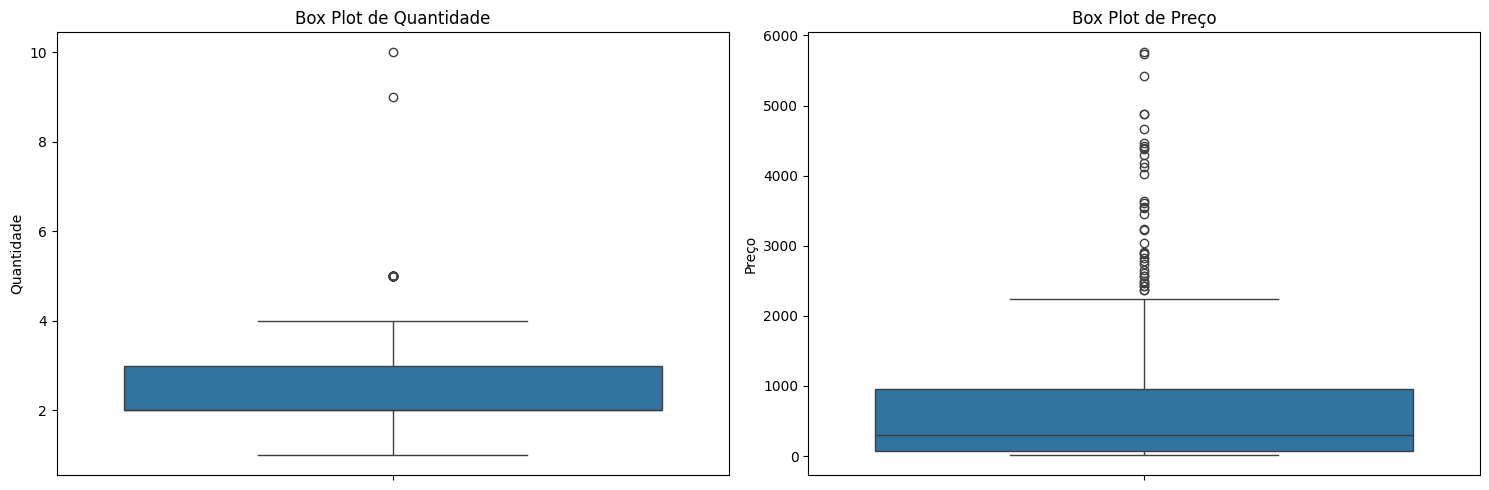

In [16]:
# Visualizando em BoxPlot a distribuição de Quantidade e Preço
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(ax=axes[0], y=df_limpo['Quantidade'])
axes[0].set_title('Box Plot de Quantidade')
axes[0].set_ylabel('Quantidade')

sns.boxplot(ax=axes[1], y=df_limpo['Preço'])
axes[1].set_title('Box Plot de Preço')
axes[1].set_ylabel('Preço')

plt.tight_layout()
plt.show()

* Observações
  * Acerca de quantidade, considerando valores reais, é aceitável valores acima do limiar de 4, que não ultrapassam o valor de 10 no quesito de vendas.
  * Vale-se observar os casos de preço a fim de entender se são factuais ou não.

In [17]:
# Visualizando quem são os outliers
print("Quantidade Total:" + str(len(df_limpo[outliers_preco | outliers_quantidade])))
df_limpo[outliers_preco | outliers_quantidade]

Quantidade Total:65


,ID,Data,Produto,Categoria,Quantidade,Preço
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.110000
6,7,2023-02-19,Tablet iPad,Tablets,2.0,3614.260000
7,8,2023-08-24,HD Externo 1TB,Armazenamento,5.0,548.820000
11,12,2023-07-01,Smartphone Samsung Galaxy,Celulares,3.0,2366.460000
13,14,2023-07-14,Smartphone Samsung Galaxy,Celulares,4.0,2432.310000
15,16,2023-02-03,Smartphone Samsung Galaxy,Celulares,5.0,1582.730000
16,17,2023-09-13,Fones Bluetooth,Áudio,5.0,155.850000
18,19,2023-07-24,Tablet iPad,Tablets,5.0,2181.820000
21,22,2023-09-28,Smartphone Samsung Galaxy,Celulares,1.0,2424.510000
25,26,2023-11-17,iPhone 14,Celulares,3.0,4397.820000


* Acerca dos preços existe uma variação grande pela prórpia natureza dos tipos de produto, logo, essa analise de outliers deve ser feita sob os grupos de cada produto

In [18]:
# Procurando outliers por produto

outliers_por_produto = {}

for produto in df_limpo['Produto'].unique():
    df_produto = df_limpo[df_limpo['Produto'] == produto].copy()
    outliers_preco_produto = buscar_outliers(df_produto, 'Preço')
    outliers_quantidade_produto = buscar_outliers(df_produto, 'Quantidade')

    if outliers_preco_produto.sum() > 0 or outliers_quantidade_produto.sum() > 0:
        outliers_por_produto[produto] = df_produto[outliers_preco_produto | outliers_quantidade_produto]

print("Outliers por Produto:")
for produto, outliers_df in outliers_por_produto.items():
    print(f"\nProduto: {produto}")
    display(outliers_df)

Outliers por Produto:

Produto: Teclado Mecânico


,ID,Data,Produto,Categoria,Quantidade,Preço
149,150,2023-11-28,Teclado Mecânico,Periféricos,1.0,1441.695917



Produto: Cabo HDMI


,ID,Data,Produto,Categoria,Quantidade,Preço
1,2,2023-02-22,Cabo HDMI,Acessórios,5.0,16.11
30,31,2023-03-07,Cabo HDMI,Acessórios,5.0,48.75
197,198,2023-03-12,Cabo HDMI,Acessórios,5.0,42.60
212,213,2023-08-01,Cabo HDMI,Acessórios,5.0,16.15
268,269,2023-02-09,Cabo HDMI,Acessórios,5.0,31.19
277,278,2023-10-26,Cabo HDMI,Acessórios,5.0,19.51



Produto: Caixa de Som JBL


...

,ID,Data,Produto,Categoria,Quantidade,Preço
203,204,2023-12-12,Cadeira Gamer,Móveis,5.0,953.51



Produto: Mouse Logitech


,ID,Data,Produto,Categoria,Quantidade,Preço
263,264,2023-12-02,Mouse Logitech,Periféricos,5.0,208.26



Produto: SSD 512GB


,ID,Data,Produto,Categoria,Quantidade,Preço
123,124,2023-08-26,SSD 512GB,Armazenamento,2.0,2783.28372


* A partir dos dados acima é possível realizar um comparativo com preços reais a fim de entender se os dados estão dentro do esperado.
Partindo de um conjunto de dados exemplo:




In [35]:
# @title
from IPython.display import display, HTML

display(HTML("""
<table>
<tr><th>Nome do produto</th><th>Preço de mercado (R$)</th></tr>
<tr><td><b>Cabo HDMI</b></td><td>R$ 15 – R$ 50</td></tr>
<tr><td><b>Pen Drive 64GB</b></td><td>R$ 25 – R$ 80</td></tr>
<tr><td><b>Carregador USB-C</b></td><td>R$ 30 – R$ 80</td></tr>
<tr><td><b>Mouse Logitech</b></td><td>R$ 80 – R$ 250</td></tr>
<tr><td><b>Mousepad Gamer</b></td><td>R$ 50 – R$ 200</td></tr>
<tr><td><b>Fones Bluetooth</b></td><td>R$ 100 – R$ 500</td></tr>
<tr><td><b>Webcam Full HD</b></td><td>R$ 150 – R$ 400</td></tr>
<tr><td><b>Roteador Wi-Fi</b></td><td>R$ 150 – R$ 500</td></tr>
<tr><td><b>Teclado Mecânico</b></td><td>R$ 200 – R$ 800</td></tr>
<tr><td><b>Caixa de Som JBL</b></td><td>R$ 200 – R$ 800</td></tr>
<tr><td><b>HD Externo 1TB</b></td><td>R$ 300 – R$ 600</td></tr>
<tr><td><b>SSD 512GB</b></td><td>R$ 400 – R$ 800</td></tr>
<tr><td><b>Impressora HP</b></td><td>R$ 400 – R$ 1.200</td></tr>
<tr><td><b>Mesa de Escritório</b></td><td>R$ 600 – R$ 1.800</td></tr>
<tr><td><b>Monitor Samsung 24"</b></td><td>R$ 800 – R$ 1.500</td></tr>
<tr><td><b>Cadeira Gamer</b></td><td>R$ 800 – R$ 2.500</td></tr>
<tr><td><b>Smartphone Samsung Galaxy</b></td><td>R$ 1.200 – R$ 3.000</td></tr>
<tr><td><b>Tablet iPad</b></td><td>R$ 2.000 – R$ 4.000</td></tr>
<tr><td><b>Notebook Dell Inspiron</b></td><td>R$ 2.500 – R$ 4.500</td></tr>
<tr><td><b>iPhone 14</b></td><td>R$ 4.000 – R$ 6.000</td></tr>
</table>
"""))


Nome do produto,Preço de mercado (R$)
Cabo HDMI,R$ 15 – R$ 50
Pen Drive 64GB,R$ 25 – R$ 80
Carregador USB-C,R$ 30 – R$ 80
Mouse Logitech,R$ 80 – R$ 250
Mousepad Gamer,R$ 50 – R$ 200
Fones Bluetooth,R$ 100 – R$ 500
Webcam Full HD,R$ 150 – R$ 400
Roteador Wi-Fi,R$ 150 – R$ 500
Teclado Mecânico,R$ 200 – R$ 800
Caixa de Som JBL,R$ 200 – R$ 800


Os produtos que foram identificados fora do range padrão do mercado foram:
* O Teclado de ID 150 com o valor de RS 1441.70 que ultrapassa o maior valor identificado na tabela que é de 800 reais;
* A WebCam de ID 220 com o valor de RS 3041.16 que ultrapassa o padrão de 400 reais máximo.
* Os MousePads Gamer de IDs 74 e 295 com valores de RS 992.74 e RS 627.48, respectivamente, que são maiores que o valor máximo de 200 reais identificado na tabela.
* O SSD de ID 124 com o preço de RS 2783.28, mas o padrão limite é de 800 reais.


**DECISÃO PARA TRATAMENTO DE OUTLIERS DE PREÇO**

Considerando que a variável de preço constitui uma métrica fundamental para as análises em curso, e diante da identificação de 5 registros que apresentam valores significativamente discrepantes em relação aos parâmetros estabelecidos pelo mercado, foi determinada a seguinte ação:

**Procedimento:**
**Exclusão dos registros inconsistentes** da base de dados analítica.

**Fundamentação:**
1. **Representatividade Limitada:** Os casos identificados representam apenas 1,6% do total da base, não comprometendo a significância estatística do conjunto
2. **Magnitude da Discrepância:** Os valores excedem em mais de 80% os limites superiores estabelecidos, caracterizando anomalias evidentes
3. **Integridade Analítica:** A manutenção desses outliers distorceria substancialmente os resultados de modelos estatísticos e análises de tendência

**Salvaguarda:**
Os registros excluídos serão arquivados em base separada para eventual auditoria futura, mantendo a rastreabilidade das decisões tomadas.

Esta medida visa assegurar a confiabilidade dos insights gerados a partir da base de dados, preservando a qualidade e consistência das análises subsequentes.

In [19]:
# Separar em uma base especifica os IDs 150, 220, 74, 295 e 124
outliers_ids = [150, 220, 74, 295, 124]
outliers_df = df_limpo[df_limpo['ID'].isin(outliers_ids)]
outliers_df.to_csv('outliers.csv', index=False)

In [20]:
# Remover os outliers da base
df_limpo = df_limpo[~df_limpo['ID'].isin(outliers_ids)]

In [7]:
# identificando algum valor que é decimal em quantidade
df_limpo[df_limpo['Quantidade'] % 1 != 0]

,ID,Data,Produto,Categoria,Quantidade,Preço
120,122,2023-10-03,Webcam Full HD,Periféricos,2.5,298.12
213,217,2023-04-19,Cabo HDMI,Acessórios,2.5,16.77


In [8]:
# Arredondando valores de quantidade não inteiros
df_limpo['Quantidade'] = df_limpo['Quantidade'].round()

In [21]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295 entries, 0 to 299
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          295 non-null    int64  
 1   Data        295 non-null    object 
 2   Produto     295 non-null    object 
 3   Categoria   295 non-null    object 
 4   Quantidade  295 non-null    float64
 5   Preço       295 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 16.1+ KB


In [9]:
df_limpo.to_csv('df_limpo.csv', index=False)

## Análise de Vendas

In [3]:
vendas = pd.read_csv('df_limpo.csv')

In [10]:
# Calcular vendas totais por produto
vendas_totais = vendas.groupby('Produto')['Quantidade'].sum()

In [11]:
vendas_totais

,Quantidade
Produto,
Cabo HDMI,98.0
Cadeira Gamer,13.0
Caixa de Som JBL,35.0
Carregador USB-C,73.0
Fones Bluetooth,40.0
HD Externo 1TB,22.0
Impressora HP,5.0
Mesa de Escritório,7.0
"Monitor Samsung 24""",22.0


In [14]:
# Vendas totais de todos os produtos
print(vendas['Quantidade'].sum())

754.0


In [15]:
# Analisando o valor obtido por cada venda
vendas['Valor'] = vendas['Quantidade'] * vendas['Preço']

In [16]:
# 1. Total de vendas por produto
vendas_por_produto = vendas.groupby('Produto').agg({
            'Valor': 'sum',
            'Quantidade': 'sum',
            'ID': 'count'
        }).rename(columns={'ID': 'Num_Transações'}).sort_values('Valor', ascending=False)

In [17]:
# 2. Produto com maior número de vendas
produto_top = vendas_por_produto.index[0]
valor_top = vendas_por_produto.loc[produto_top, 'Valor']

In [18]:
# 3. Análise por categoria
vendas_por_categoria = vendas.groupby('Categoria').agg({
    'Valor': 'sum',
    'Quantidade': 'sum',
    'ID': 'count'
}).rename(columns={'ID': 'Num_Transações'}).sort_values('Valor', ascending=False)

In [20]:
resultados = {
            'vendas_por_produto': vendas_por_produto,
            'vendas_por_categoria': vendas_por_categoria,
            'produto_lider': produto_top,
            'valor_lider': valor_top,
            'total_geral': vendas['Valor'].sum()
        }

In [21]:
resultados

{'vendas_por_produto':                                 Valor  Quantidade  Num_Transações
 Produto                                                          
 iPhone 14                  170895.920        37.0              14
 Smartphone Samsung Galaxy  149106.720        73.0              30
 Tablet iPad                105616.380        36.0              10
 Notebook Dell Inspiron      26484.380         8.0               3
 Monitor Samsung 24"         24309.810        22.0               8
 Caixa de Som JBL            22576.750        35.0              12
 Cadeira Gamer               19324.350        13.0               5
 SSD 512GB                   16066.330        30.0              12
 Teclado Mecânico            15966.970        29.0              15
 Webcam Full HD              14043.360        48.0              18
 Fones Bluetooth             11887.420        40.0              17
 HD Externo 1TB              11828.090        22.0               9
 Mouse Logitech               8464.590  

In [22]:
resultados['vendas_por_produto'].to_csv('analise_vendas_por_produto.csv')
resultados['vendas_por_categoria'].to_csv('analise_vendas_por_categoria.csv')